In [2]:
from pydantic import BaseModel
from openai import OpenAI
import os, sys
sys.path.insert(0, os.path.abspath(".."))
from src.rarekg.pubmed.pubmed_central import get_pmc_fulltext
from src.rarekg.sgr import (extract_entities, ExtractionResult)


pmcid = "PMC9314610"

title, abstract, para = get_pmc_fulltext(pmcid)
print(title)
print(abstract)







Genotype–phenotype correlates in Joubert syndrome: A review
Abstract Joubert syndrome (JS) is a genetically heterogeneous primary ciliopathy characterized by a pathognomonic cerebellar and brainstem malformation, the “molar tooth sign,” and variable organ involvement. Over 40 causative genes have been identified to date, explaining up to 94% of cases. To date, gene‐phenotype correlates have been delineated only for a handful of genes, directly translating into improved counseling and clinical care. For instance, JS individuals harboring pathogenic variants in TMEM67 have a significantly higher risk of liver fibrosis, while pathogenic variants in NPHP1 , RPGRIP1L , and TMEM237 are frequently associated to JS with renal involvement, requiring a closer monitoring of liver parameters, or renal functioning. On the other hand, individuals with causal variants in the CEP290 or AHI1 need a closer surveillance for retinal dystrophy and, in case of CEP290 , also for chronic kidney disease. These

In [48]:
from difflib import SequenceMatcher

def norm_text(s: str) -> str:
    """Lowercase + collapse whitespace for more stable similarity."""
    return " ".join(s.strip().split()).lower()

def similarity_percent(a: str, b: str) -> float:
    """
    Return similarity between a and b as a percentage in [0, 100].
    Uses difflib.SequenceMatcher on normalized text.
    """
    a_norm = norm_text(a)
    b_norm = norm_text(b)
    ratio = SequenceMatcher(None, a_norm, b_norm).ratio()
    return ratio * 100.0


In [35]:
print(similarity_percent("joubert syndrome", "joubert syndrome related disorders"))
print(similarity_percent("acrocallosal syndrome (acls)", "acrocallosal syndrome"))
print(similarity_percent("js with oculorenal involvement", "js with ocular involvement"))
print(similarity_percent("js with oculorenal involvement", "js with renal involvement"))
s1 = "corpus callosum anomalies"
s2 = "corpus callosum abnormalities"
print(similarity_percent(s1, s2))  # e.g. 93.5


64.0
85.71428571428571
89.28571428571429
90.9090909090909
92.5925925925926


In [3]:
from typing import Set, Tuple, Union, Dict, Any
import json


def _normalize_entity_name(name: str) -> str:
    """
    Very simple text normalization for comparison:
      - lowercase
      - strip leading/trailing whitespace
      - collapse internal whitespace

    You can later extend this (e.g. Greek letters, hyphens, punctuation).
    """
    name = name.strip().lower()
    # collapse multiple spaces/tabs/newlines
    parts = name.split()
    return " ".join(parts)


def _entities_from_json_like(
    data: Union[str, Dict[str, Any], ExtractionResult]
) -> Set[Tuple[str, str]]:
   
    if isinstance(data, ExtractionResult):
        ents = data.entities
        result: Set[Tuple[str, str]] = set()
        for e in ents:
            if hasattr(e.type, "value"):
                etype = e.type.value
            else:
                etype = str(e.type)
                if "." in etype:
                    etype = etype.split(".")[-1]

            if etype == "gene":
                name = e.name              # no normalization
            else:
                name = _normalize_entity_name(e.name)
            result.add((name, etype))
        return result
    
    if isinstance(data, str):
        data = json.loads(data)

    entities = data.get("entities", [])
    result: Set[Tuple[str, str]] = set()
    for ent in entities:
        name = ent.get("name")
        etype = ent.get("type")
        if not name or not etype:
            continue
        if etype == "gene":
            norm_name = name  # keep as is
        else:
            norm_name = _normalize_entity_name(name)

        result.add((norm_name, str(etype)))
    return result


def evaluate_extraction(
    gold: Union[str, Dict[str, Any], ExtractionResult],
    pred: Union[str, Dict[str, Any], ExtractionResult],
) -> Dict[str, float]:
    gold_set = _entities_from_json_like(gold)
    pred_set = _entities_from_json_like(pred)

    tp = len(gold_set & pred_set)
    fp = len(pred_set - gold_set)
    fn = len(gold_set - pred_set)

    num_gold = len(gold_set)
    num_pred = len(pred_set)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "true_positives": float(tp),
        "false_positives": float(fp),
        "false_negatives": float(fn),
        "num_gold": float(num_gold),
        "num_pred": float(num_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


In [21]:
import json
from pathlib import Path

json_path = Path("../golden/para_0.json")

with json_path.open("r", encoding="utf-8") as f:
    gold_p1 = json.load(f)

print(gold_p1.keys())        # -> dict with "entities"
print(gold_p1["entities"][:2])
i=8
print(gold_p1["entities"][i]["type"] == "gene")
print(gold_p1["entities"][i]["type"])
ab = _entities_from_json_like(gold_p1)
print(ab)

dict_keys(['entities'])
[{'name': 'Joubert syndrome', 'type': 'rare_disease'}, {'name': 'cerebellar malformation', 'type': 'phenotype'}]
True
gene
{('molar tooth sign', 'phenotype'), ('liver fibrosis', 'phenotype'), ('retinal dystrophy', 'phenotype'), ('NPHP1', 'gene'), ('brainstem malformation', 'phenotype'), ('joubert syndrome', 'rare_disease'), ('cerebellar malformation', 'phenotype'), ('RPGRIP1L', 'gene'), ('TMEM67', 'gene'), ('chronic kidney disease', 'phenotype'), ('AHI1', 'gene'), ('TMEM237', 'gene'), ('CEP290', 'gene')}


In [18]:
print(para[20])

Neurodevelopmental features in JS are related to the underlying brain malformation and, as such, represent constant features of the syndrome, and usually the earliest to manifest. These consist in neonatal hypotonia, abnormal eye movements (mainly ocular motor apraxia, OMA), and breathing dysregulation (apneas and/or hyperpneas usually resolving within few months of life). A delay of developmental milestones becomes evident soon after, followed by ataxia (with broad‐based, unsteady gait and difficulties in running or climbing stairs) and intellectual disability of variable severity; nevertheless, a minority of individuals have borderline, or even normal cognitive functions (Bulgheroni et al., 2016 ; Poretti, Alber, Bürki, Toelle, & Boltshauser, 2009 ; Summers et al., 2017 ). Notably, Poretti et al. reported that neuroimaging may predict the neurodevelopmental outcome, as a high degree of vermis hypoplasia was found to correlate with worse prognosis (Poretti et al., 2017 ). Of note, exp

In [4]:
client = OpenAI(base_url="http://localhost:8000/v1", api_key="dummy")

In [5]:
import re

# Very simple pattern: parentheses with at least one 4-digit year
CITATION_RE = re.compile(
    r"\((?:[^()]*?\d{4}[^()]*)\)"
)

def strip_inline_citations(text: str) -> str:
    return CITATION_RE.sub("", text)

ETAL_RE = re.compile(r"\b[A-Z][a-z]+ et al\.\b")

def strip_citation_like_bits(text: str) -> str:
    text = CITATION_RE.sub("", text)
    text = ETAL_RE.sub("", text)
    return text


In [ ]:
sgr_all = """
You are a precise biomedical entity tagger.
Follow the next rules silently, do NOT output any reason.

INTERNAL SGR LOOP (keep private; do not output):

1. IDENTIFY candidates by type with its canonical name:
    - rare_disease: named rare disorders (Orphanet-style labels; prevalence < 1/2000 or clearly used as a specific rare condition).
    - gene: HGNC-like symbols in ALL-CAPS (optionally with digits/hyphen) or explicit gene phrases (e.g. "breast cancer 1 gene").
    - genotype: HGVS-style sequence variants only (e.g. "c.123A>G", "NM_000123.3:c.123A>G").
    - phenotype: specific phenotypic abnormalities; without modifiers, inheritance, frequency.
    - treatment: therapy/management strategies or procedures (e.g. "enzyme replacement therapy", "bone marrow transplantation").
    - drug: concrete medicinal substances or products (e.g. "alglucosidase alfa", "miglustat").

2. VALIDATE (soft checks; silently discard failures):

    2.1 rare_disease:
      - If a phrase clearly functions as the disease name even if it contains phenotype words, extract it:
        e.g. "microcephaly with pontine and cerebellar hypoplasia".
      - Do NOT extract classes of diseases: e.g. "lysosomal storage disease".
      - If the name is just an alias, do not extract it.

    2.2 gene:
      - Valid gene symbols are ALL-CAPS with letters/digits and at most a small number of characters (e.g. "TMEM67", "CEP290").
      - Explicit gene phrases like "breast cancer 1 gene" are allowed, but must clearly describe a gene.

    2.3 genotype:
      - Valid only if the string matches HGVS-style formats: c.* or NM_*:c.*.
      - Do NOT guess genotypes from plain text descriptions.

    2.4 phenotype:
      - Phenotypes are abnormalities, not normal findings. 
      - Exclude inheritance terms, course, frequency, or general patient descriptions, or general description of a phenotype.
      - Also accept single-word or fixed phrases that are already phenotype labels (e.g. microcephaly, polymicrogyria, hydrocephalus, ataxia).
      - Also accept "issue + place/function" patterns that combine an abnormality word with an organ/structure/function 
          but never pure locations without the abnormality word.
      - In shared-head coordinated mentions, split into separate phenotypes:
        e.g. "cerebellar and brainstem malformation" -> "cerebellar malformation", "brainstem malformation".

    2.5 treatment:
      - Include concrete therapies/management strategies (e.g. "enzyme replacement therapy").
      - Exclude vague mentions like "future treatments" or generic "surgeries".

    2.6 drug:
      - Include specific drug substances/products (e.g. "alglucosidase alfa", "miglustat").
      - Exclude broad classes like "antibiotics" unless a specific drug is named.
      - Exclude words that just contain "med" or something similar in the name, but do not represent acrual medication.

3. EMIT
    Output the validated entities. If nothing valid, output exactly: {"entities":[]}
"""


In [6]:
sgr_all = """
You are a precise biomedical entity tagger.
Follow the next rules silently, do NOT output any reason.

INTERNAL SGR LOOP (keep private; do not output):

0. GENERAL NAMING RULES
    - For every entity, the name must be built from words that appear in the text.
    - Prefer a contiguous span copied exactly from the text (same spelling, hyphens, spaces).
    - You may drop leading/trailing words that are inheritance, frequency, or other modifiers,
      but you must NOT invent new words or change word order.
    - In shared-head coordinated mentions you may split them, reusing only words from the
      original phrase (e.g. "cerebellar and brainstem malformation" ->
      "cerebellar malformation", "brainstem malformation").

1. IDENTIFY candidates by type with its canonical name:
    - rare_disease: named rare disorders (Orphanet-style labels; prevalence < 1/2000 or clearly used as a specific rare condition).
    - gene: HGNC-like symbols in ALL-CAPS (optionally with digits/hyphen) or explicit gene phrases (e.g. "breast cancer 1 gene").
    - genotype: HGVS-style sequence variants only (e.g. "c.123A>G", "NM_000123.3:c.123A>G").
    - phenotype: specific phenotypic abnormalities; without modifiers, inheritance, frequency.
    - treatment: therapy/management strategies or procedures (e.g. "enzyme replacement therapy", "bone marrow transplantation").
    - drug: concrete medicinal substances or products (e.g. "alglucosidase alfa", "miglustat").

2. VALIDATE (soft checks; silently discard failures):

    2.1 rare_disease:
      - If a phrase clearly functions as the disease name even if it contains phenotype words, extract it:
        e.g. "microcephaly with pontine and cerebellar hypoplasia".
      - Do NOT extract classes of diseases: e.g. "lysosomal storage disease".
      - Do NOT extract acronyms as rare_disease (e.g. "JS", "JS-O", "MKS", "MTS").
        Only the long-form disease names are allowed.
      - If the name is just an alias, do not extract it.

    2.2 gene:
      - Valid gene symbols are ALL-CAPS with letters/digits and at most a small number of characters (e.g. "TMEM67", "CEP290").
      - Explicit gene phrases like "breast cancer 1 gene" are allowed, but must clearly describe a gene.

    2.3 genotype:
      - Valid only if the string matches HGVS-style formats: c.* or NM_*:c.*.
      - Do NOT guess genotypes from plain text descriptions.

    2.4 phenotype:
      - Phenotypes are abnormalities, not normal findings.
      - Exclude inheritance terms, course, frequency, or general patient descriptions, or general description of a phenotype.
      - Also accept single-word or fixed phrases that are already phenotype labels (e.g. microcephaly, polymicrogyria, hydrocephalus, ataxia).
      - Also accept "issue + place/function" patterns that combine an abnormality word with an organ/structure/function,
        but never pure locations without the abnormality word (e.g. do NOT extract "midbrain–hindbrain junction" alone).
      - In shared-head coordinated mentions, split into separate phenotypes:
        e.g. "cerebellar and brainstem malformation" -> "cerebellar malformation", "brainstem malformation".

    2.5 treatment:
      - Include concrete therapies/management strategies (e.g. "enzyme replacement therapy").
      - Exclude vague mentions like "future treatments" or generic "surgeries".
      - Do NOT extract acronyms as treatment names.

    2.6 drug:
      - Include specific drug substances/products (e.g. "alglucosidase alfa", "miglustat").
      - Exclude broad classes like "antibiotics" unless a specific drug is named.
      - Exclude words that just contain "med" or something similar in the name, but do not represent actual medication.
      - Do NOT extract acronyms as drug names.

    2.7 acronyms (general rule):
      - For rare_disease, phenotype, treatment, and drug:
          do NOT extract pure acronyms or short ALL-CAPS forms (e.g. "JS", "JS-O", "MTS").
          Only the long-form names should be extracted.
      - Gene and genotype symbols are allowed to be ALL-CAPS or short codes as long as they match the gene/genotype rules above.

3. EMIT
    Output the validated entities. If nothing valid, output exactly: {"entities":[]}
"""


In [11]:
SGR_pheno = """
You are a precise biomedical PHENOTYPE extractor.
Extract ONLY phenotypic abnormalities and return JSON with key "entities"
according to the provided schema.

GENERAL

- Each phenotype name must be a contiguous span copied EXACTLY from the text
  (same spelling, capitalization, hyphens, spaces).
- Do NOT invent or rephrase terms.
- If there are no phenotypes, return exactly: {"entities": []}.

1. NAMED PHENOTYPES

Accept phenotype terms that are already labels, for example (forms only):
  • polymicrogyria, microcephaly, cerebellar hypoplasia, hydrocephalus,
    scoliosis, intellectual disability, encephalocele, etc.
  • phrases like "chronic tubulointerstitial nephropathy",
    "corticomedullary cysts".

Heuristics:
  • often end in: -pathy, -plasia, -osis, -itis, -emia, -uria,
    -cephaly, -gyria, -cele, -megaly,
  • or are well-known clinical words (as above).

Rule: if it looks like a named phenotype term, copy it as-is and mark it
as type "phenotype".

2. ISSUE + PLACE / FUNCTION PATTERNS

Accept phrases of the form:
  [abnormality word/phrase] + [organ / structure / function / process]

Examples (forms only):
  • small kidneys, scarred kidneys
  • increased echogenicity at the corticomedullary junction
  • pigmentary irregularities of the retina
  • growth failure
  • breathing dysregulation, episodic breathing dysregulation
  • recurrent infections

Abnormality words include things like:
  small, enlarged, scarred, hypoplastic, hyperplastic, abnormal,
  irregular, defective, impaired, failure, deficiency, degeneration,
  cysts, fibrosis, hamartoma, malformation, dysplasia, stenosis,
  obstruction, etc.

Rules:
  • The span must include BOTH an abnormality word/phrase AND the
    affected organ/structure/function/process (if it is mentioned).
  • Prefer the shortest span that still clearly expresses
    "issue + place/function".

3. EXCLUDE NON-PHENOTYPES

Do NOT output as phenotypes:

  • Pure locations without an abnormality word:
      "heart valves", "joints", "gait", "kidneys", "retina",
      "midbrain–hindbrain junction", "corpus callosum",
      "eye", "liver", "hands", "feet", "skeleton", etc.

  • Pure issue words with no clear target:
      vague "migration defects", "involvement" alone, e.g.
      "renal involvement", "hepatic involvement".

  • Generic category phrases:
      "multi-system involvement", "skeletal abnormalities",
      "psychiatric symptoms" (when used as broad categories).

  • Meta concepts:
      "phenotypic spectrum", "clinical picture",
      "disease complications", etc.

  • Pure inheritance / course / frequency / general patient description:
      "autosomal recessive", "X-linked", "progressive", "recurrent",
      "chronic", "episodic", "severe clinical course",
      "complex phenotype" when not tied to a specific abnormality.

If such words appear together with a clear abnormal issue + space,
keep only the shortest span that includes the abnormal issue + space.

4. SHARED-HEAD COORDINATED MENTIONS

For coordinated mentions with a shared head, you may split them, e.g.:
  "cerebellar and brainstem malformation"
    → "cerebellar malformation"
    → "brainstem malformation"

Use only forms that are obvious from the wording; do NOT invent new words.

OUTPUT

- For each valid phenotype:
    { "name": <copied text>, "type": "phenotype" }
- If none, return: {"entities": []}
"""


In [12]:
from src.rarekg.sgr import (SGR_RD_PROMPT, SGR_Pheno_PROMPT, SGR_treatment_PROMPT)
text = strip_citation_like_bits(abstract)
pred_rd = extract_entities(
    text,
    client,
    model="medgemma",
    system_prompt= SGR_RD_PROMPT,
    use_response_format=False,   # vLLM: use guided_json
)
pred_pheno = extract_entities(
    text,
    client,
    model="medgemma",
    system_prompt= SGR_Pheno_PROMPT,
    use_response_format=False,   # vLLM: use guided_json
)
result = _entities_from_json_like(pred_rd) | _entities_from_json_like(pred_pheno)
pred_treatment = extract_entities(
    text,
    client,
    model="medgemma",
    system_prompt= SGR_treatment_PROMPT,
    use_response_format=False,   # vLLM: use guided_json
)

result = result | _entities_from_json_like(pred_treatment)



print (result)

{('NPHP1', 'gene'), ('TMEM237', 'gene'), ('RPGRIP1L', 'gene'), ('TMEM67', 'gene'), ('CEP290', 'gene'), ('joubert syndrome', 'rare_disease'), ('AHI1', 'gene'), ('molar tooth sign', 'phenotype')}


In [ ]:
 metrics = evaluate_extraction(, result)
    total_tp_m += metrics["true_positives"]
    total_fp_m += metrics["false_positives"]
    total_fn_m += metrics["false_negatives"]

precision_m = total_tp_m/ (total_tp_m+ total_fp_m) if (total_tp_m+ total_fp_m) > 0 else 0.0
recall_m    = total_tp_m/ (total_tp_m+ total_fn_m) if (total_tp_m+ total_fn_m) > 0 else 0.0
f1_m = (
    2 * precision_m * recall_m / (precision_m + recall_m)
    if (precision_m + recall_m) > 0
    else 0.0
)

print("Precision:", precision_m)
print("Recall:", recall_m)
print("F1:", f1_m)

In [7]:
from pathlib import Path
import json

golden_dir = Path("../golden")

total_tp_m = total_fp_m = total_fn_m = 0

for i in range(0, 14):  
    path = golden_dir / f"para_{i}.json" 

    if not path.exists():
        print(f"Missing file: {path}")
        continue

    with path.open("r", encoding="utf-8") as f:
        gold = json.load(f)

    if i == 0:
        text = strip_citation_like_bits(abstract)
        pred_i_json = extract_entities(
            text,
            client,
            model="medgemma",
            system_prompt= sgr_all,
            use_response_format=False,   # vLLM: use guided_json
        )
    elif 1<=i<=3:
        text = strip_citation_like_bits(para[i-1])
        pred_i_json = extract_entities(
        text,
        client,
        model="medgemma",
        system_prompt= sgr_all,
        use_response_format=False,   # vLLM: use guided_json
    )
    else:
        text = strip_citation_like_bits(para[i+6])
        pred_i_json = extract_entities(
        text,
        client,
        model="medgemma",
        system_prompt= sgr_all,
        use_response_format=False,   # vLLM: use guided_json
    )
        
    print(i)
    print(_entities_from_json_like(pred_i_json))
    print(_entities_from_json_like(gold))
    metrics = evaluate_extraction(gold, pred_i_json)
    total_tp_m += metrics["true_positives"]
    total_fp_m += metrics["false_positives"]
    total_fn_m += metrics["false_negatives"]

precision_m = total_tp_m/ (total_tp_m+ total_fp_m) if (total_tp_m+ total_fp_m) > 0 else 0.0
recall_m    = total_tp_m/ (total_tp_m+ total_fn_m) if (total_tp_m+ total_fn_m) > 0 else 0.0
f1_m = (
    2 * precision_m * recall_m / (precision_m + recall_m)
    if (precision_m + recall_m) > 0
    else 0.0
)

print("Precision:", precision_m)
print("Recall:", recall_m)
print("F1:", f1_m)

0
{('NPHP1', 'gene'), ('TMEM237', 'gene'), ('RPGRIP1L', 'gene'), ('TMEM67', 'gene'), ('CEP290', 'gene'), ('joubert syndrome', 'rare_disease'), ('AHI1', 'gene'), ('molar tooth sign', 'phenotype')}
{('NPHP1', 'gene'), ('TMEM237', 'gene'), ('liver fibrosis', 'phenotype'), ('retinal dystrophy', 'phenotype'), ('TMEM67', 'gene'), ('cerebellar malformation', 'phenotype'), ('RPGRIP1L', 'gene'), ('CEP290', 'gene'), ('joubert syndrome', 'rare_disease'), ('AHI1', 'gene'), ('brainstem malformation', 'phenotype'), ('molar tooth sign', 'phenotype'), ('chronic kidney disease', 'phenotype')}
1
{('vermian dysplasia', 'phenotype'), ('superior cerebellar peduncles', 'phenotype'), ('interpeduncular fossa', 'phenotype'), ('joubert syndrome', 'rare_disease'), ('molar tooth sign', 'phenotype'), ('midbrain–hindbrain junction', 'phenotype'), ('cerebellar hypoplasia', 'phenotype')}
{('horizontally oriented superior cerebellar peduncles', 'phenotype'), ('abnormally deep interpeduncular fossa', 'phenotype'), ('ve

In [9]:
import matplotlib.pyplot as plt

def plot_prf(precision, recall, f1, model_name="Model"):
    metrics = ["Precision", "Recall", "F1"]
    values = [precision, recall, f1]

    x = range(len(metrics))  

    plt.figure(figsize=(8, 5))
    plt.bar(x, values, width=0.3)  

    plt.ylim(0, 1.0)
    plt.xticks(x, metrics)
    plt.ylabel("Score")
    plt.title(f"Entity Extraction ({model_name}): Precision / Recall / F1")
    plt.tight_layout()
    plt.show()

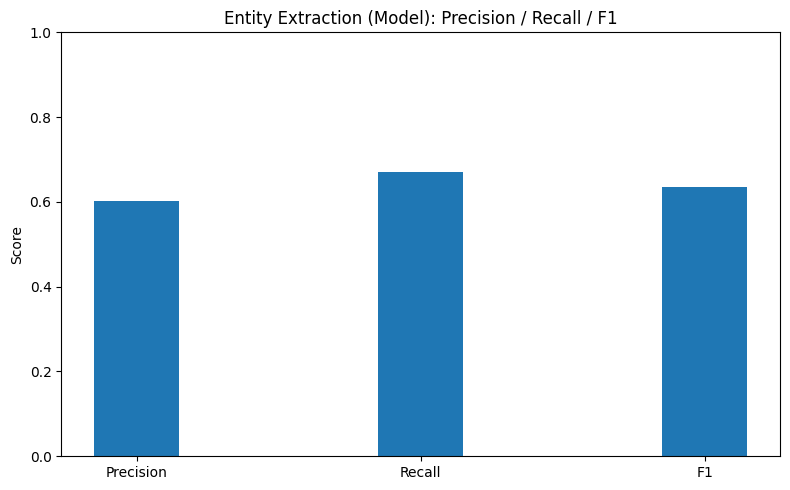

In [10]:
plot_prf(precision_m,recall_m, f1_m)

1
{('superior cerebellar peduncles', 'phenotype'), ('interpeduncular fossa', 'phenotype'), ('cerebellar hypoplasia', 'phenotype'), ('joubert syndrome (js)', 'rare_disease'), ('molar tooth sign', 'phenotype'), ('vermian dysplasia', 'phenotype')}
{('thick superior cerebellar peduncles', 'phenotype'), ('brainstem malformations', 'phenotype'), ('joubert syndrome', 'rare_disease'), ('malformation of the midbrain–hindbrain junction', 'phenotype'), ('cerebellar hypoplasia', 'phenotype'), ('horizontally oriented superior cerebellar peduncles', 'phenotype'), ('cerebellar malformations', 'phenotype'), ('molar tooth sign', 'phenotype'), ('vermian dysplasia', 'phenotype'), ('abnormally deep interpeduncular fossa', 'phenotype')}
2
{('ocular motor apraxia', 'phenotype'), ('cognitive impairment', 'phenotype'), ('joubert syndrome', 'rare_disease'), ('hypotonia', 'phenotype'), ('episodic breathing dysregulation', 'phenotype'), ('cerebellar ataxia', 'phenotype'), ('facial dysmorphisms', 'phenotype'), ('

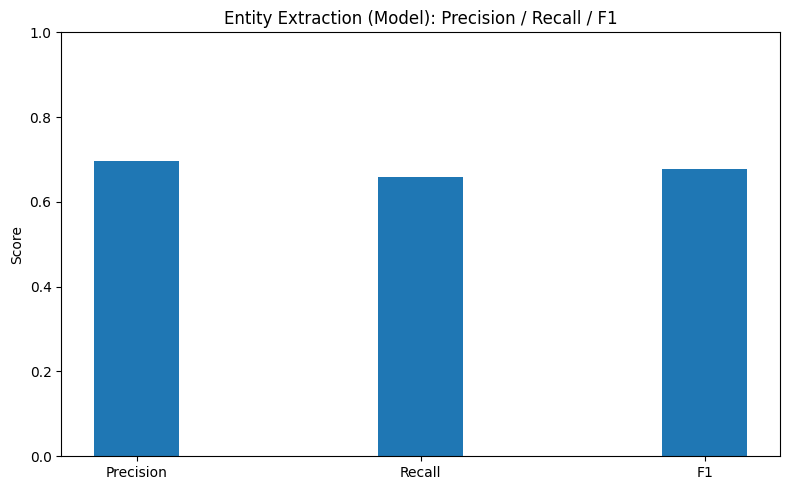

In [42]:
from pathlib import Path
import json

golden_dir = Path("../golden")

total_tp_l= total_fp_l= total_fn_l= 0

for i in range(1, 14):  
    path = golden_dir / f"para_{i}.json" 

    if not path.exists():
        print(f"Missing file: {path}")
        continue

    with path.open("r", encoding="utf-8") as f:
        gold = json.load(f)

    if i == 0:
        pred_i_json = extract_entities(
            abstract,
            client,
            model="llama",
            system_prompt= sgr_all,
            use_response_format=False,   # vLLM: use guided_json
        )
        
    elif 1<=i<=3:
        pred_i_json = extract_entities(
        para[i-1],
        client,
        model="llama",
        system_prompt= sgr_all,
        use_response_format=False,   # vLLM: use guided_json
    )
    else:
        pred_i_json = extract_entities(
        para[i+6],
        client,
        model="llama",
        system_prompt= sgr_all,
        use_response_format=False,   # vLLM: use guided_json
    )
        
    print(i)
    print(_entities_from_json_like(pred_i_json))
    print(_entities_from_json_like(gold))
    metrics = evaluate_extraction(gold, pred_i_json)
    total_tp_l+= metrics["true_positives"]
    total_fp_l+= metrics["false_positives"]
    total_fn_l+= metrics["false_negatives"]


precision_l = total_tp_l/ (total_tp_l+ total_fp_l) if (total_tp_l+ total_fp_l) > 0 else 0.0
recall_l    = total_tp_l/ (total_tp_l+ total_fn_l) if (total_tp_l+ total_fn_l) > 0 else 0.0
f1_l= (
    2 * precision_l * recall_l / (precision_l + recall_l)
    if (precision_l + recall_l) > 0
    else 0.0
)

print("Precision:", precision_l)
print("Recall:", recall_l)
print("F1:", f1_l)
plot_prf(precision_l,recall_l, f1_l)



In [46]:
print(abstract)
for i in range(0, (len(para)-1)):
    print(para[i])

Abstract Joubert syndrome (JS) is a genetically heterogeneous primary ciliopathy characterized by a pathognomonic cerebellar and brainstem malformation, the “molar tooth sign,” and variable organ involvement. Over 40 causative genes have been identified to date, explaining up to 94% of cases. To date, gene‐phenotype correlates have been delineated only for a handful of genes, directly translating into improved counseling and clinical care. For instance, JS individuals harboring pathogenic variants in TMEM67 have a significantly higher risk of liver fibrosis, while pathogenic variants in NPHP1 , RPGRIP1L , and TMEM237 are frequently associated to JS with renal involvement, requiring a closer monitoring of liver parameters, or renal functioning. On the other hand, individuals with causal variants in the CEP290 or AHI1 need a closer surveillance for retinal dystrophy and, in case of CEP290 , also for chronic kidney disease. These examples highlight how an accurate description of the range